In [2]:
#MLR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
path = r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 7\Multiple Linear Regression\ToyotaCorolla - MLR.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(1436, 11)


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


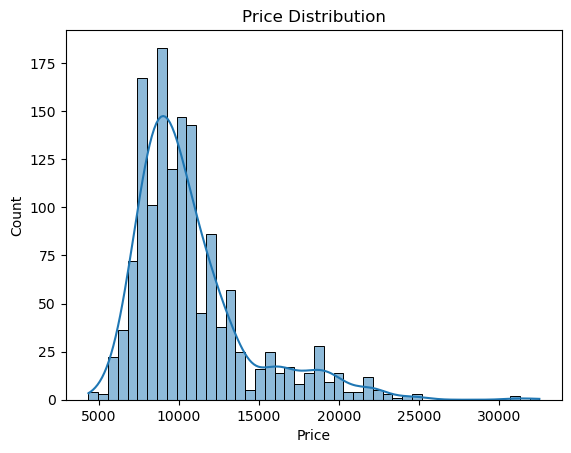

In [3]:
df.info()

df.describe()

sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

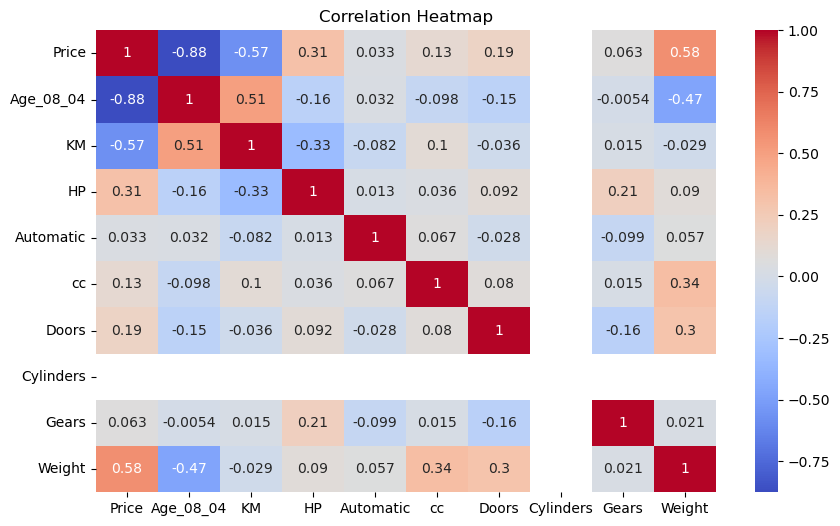

In [4]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [5]:
df = df.drop_duplicates()

# Remove constant columns
df = df.loc[:, df.nunique() > 1]

# Separate X and y
X = df.drop("Price", axis=1)
y = df["Price"]

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(cat_cols))
print("Numerical:", list(num_cols))

Categorical: ['Fuel_Type']
Numerical: ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1148, 9)
(287, 9)


In [7]:
# Preprocessing
preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

# MLR model
model1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("R2 Score:", r2_score(y_test, pred1))
print("MAE:", mean_absolute_error(y_test, pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred1)))

R2 Score: 0.8203213869961808
MAE: 986.4966877482508
RMSE: 1468.2058289421216


In [8]:
# Select important variables
features = [c for c in 
            ["Age_08_04", "KM", "HP", "Weight", "Automatic", "Fuel_Type", "cc", "Doors"]
            if c in df.columns]

X2 = df[features]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.20, random_state=42
)

cat2 = X2.select_dtypes(include="object").columns
num2 = X2.select_dtypes(exclude="object").columns

prep2 = ColumnTransformer([
    ("num", "passthrough", num2),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat2)
])

model2 = Pipeline([
    ("preprocessor", prep2),
    ("model", LinearRegression())
])

model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)

print("R2 Score:", r2_score(y2_test, pred2))
print("MAE:", mean_absolute_error(y2_test, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, pred2)))

R2 Score: 0.8173131933294029
MAE: 988.0261956053147
RMSE: 1480.445222887852


In [9]:
# Log transform selected variables
X3 = X.copy()

for col in ["KM", "cc", "Weight"]:
    if col in X3.columns:
        X3[col] = np.log1p(X3[col])

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.20, random_state=42
)

cat3 = X3.select_dtypes(include="object").columns
num3 = X3.select_dtypes(exclude="object").columns

prep3 = ColumnTransformer([
    ("num", "passthrough", num3),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat3)
])

model3 = Pipeline([
    ("preprocessor", prep3),
    ("model", LinearRegression())
])

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

print("R2 Score:", r2_score(y3_test, pred3))
print("MAE:", mean_absolute_error(y3_test, pred3))
print("RMSE:", np.sqrt(mean_squared_error(y3_test, pred3)))

R2 Score: 0.8182251334655276
MAE: 1031.3859513289074
RMSE: 1476.745540086881


In [10]:
results = pd.DataFrame({
    "Model": ["MLR Full", "MLR Reduced", "MLR Log"],
    "R2": [
        r2_score(y_test, pred1),
        r2_score(y2_test, pred2),
        r2_score(y3_test, pred3)
    ],
    "MAE": [
        mean_absolute_error(y_test, pred1),
        mean_absolute_error(y2_test, pred2),
        mean_absolute_error(y3_test, pred3)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred1)),
        np.sqrt(mean_squared_error(y2_test, pred2)),
        np.sqrt(mean_squared_error(y3_test, pred3))
    ]
})

results

,Model,R2,MAE,RMSE
0,MLR Full,0.820321,986.496688,1468.205829
1,MLR Reduced,0.817313,988.026196,1480.445223
2,MLR Log,0.818225,1031.385951,1476.745540


In [11]:
# Standardization for Ridge/Lasso
scaled_prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

ridge = Pipeline([
    ("preprocessor", scaled_prep),
    ("model", Ridge(alpha=10))
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge R2: 0.8251649119964484
Ridge RMSE: 1448.2817194124632


In [12]:
lasso = Pipeline([
    ("preprocessor", scaled_prep),
    ("model", Lasso(alpha=10, max_iter=10000))
])

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Lasso R2: 0.8295924740774198
Lasso RMSE: 1429.8258230343738


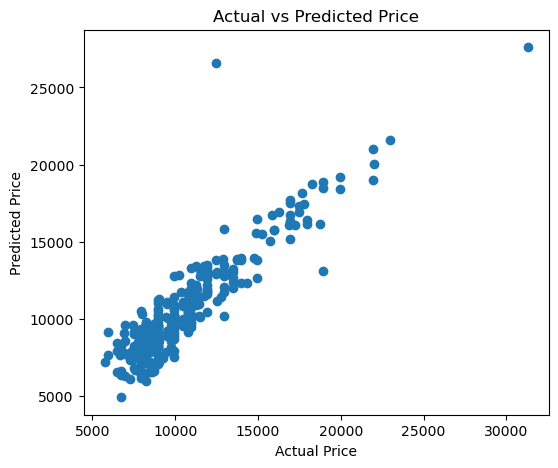

In [13]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, pred1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [14]:
Q1. What is Normalization and Standardization?

Normalization scales data to a fixed range, usually 0 to 1.

Formula:
X' = (X - Xmin) / (Xmax - Xmin)

Standardization converts data to mean 0 and standard deviation 1.

Formula:
Z = (X - Mean) / Standard Deviation

They are useful when variables have different scales. Standardization is particularly
important for Ridge and Lasso because their regularization penalties depend on
coefficient size.


Q2. How can multicollinearity be addressed?

1. Remove highly correlated variables.
2. Use VIF to identify multicollinearity.
3. Use Ridge Regression.
4. Use Lasso Regression.
5. Use PCA/dimensionality reduction.
6. Combine correlated variables using feature engineering.

SyntaxError: unterminated string literal (detected at line 6) (2248881198.py, line 6)